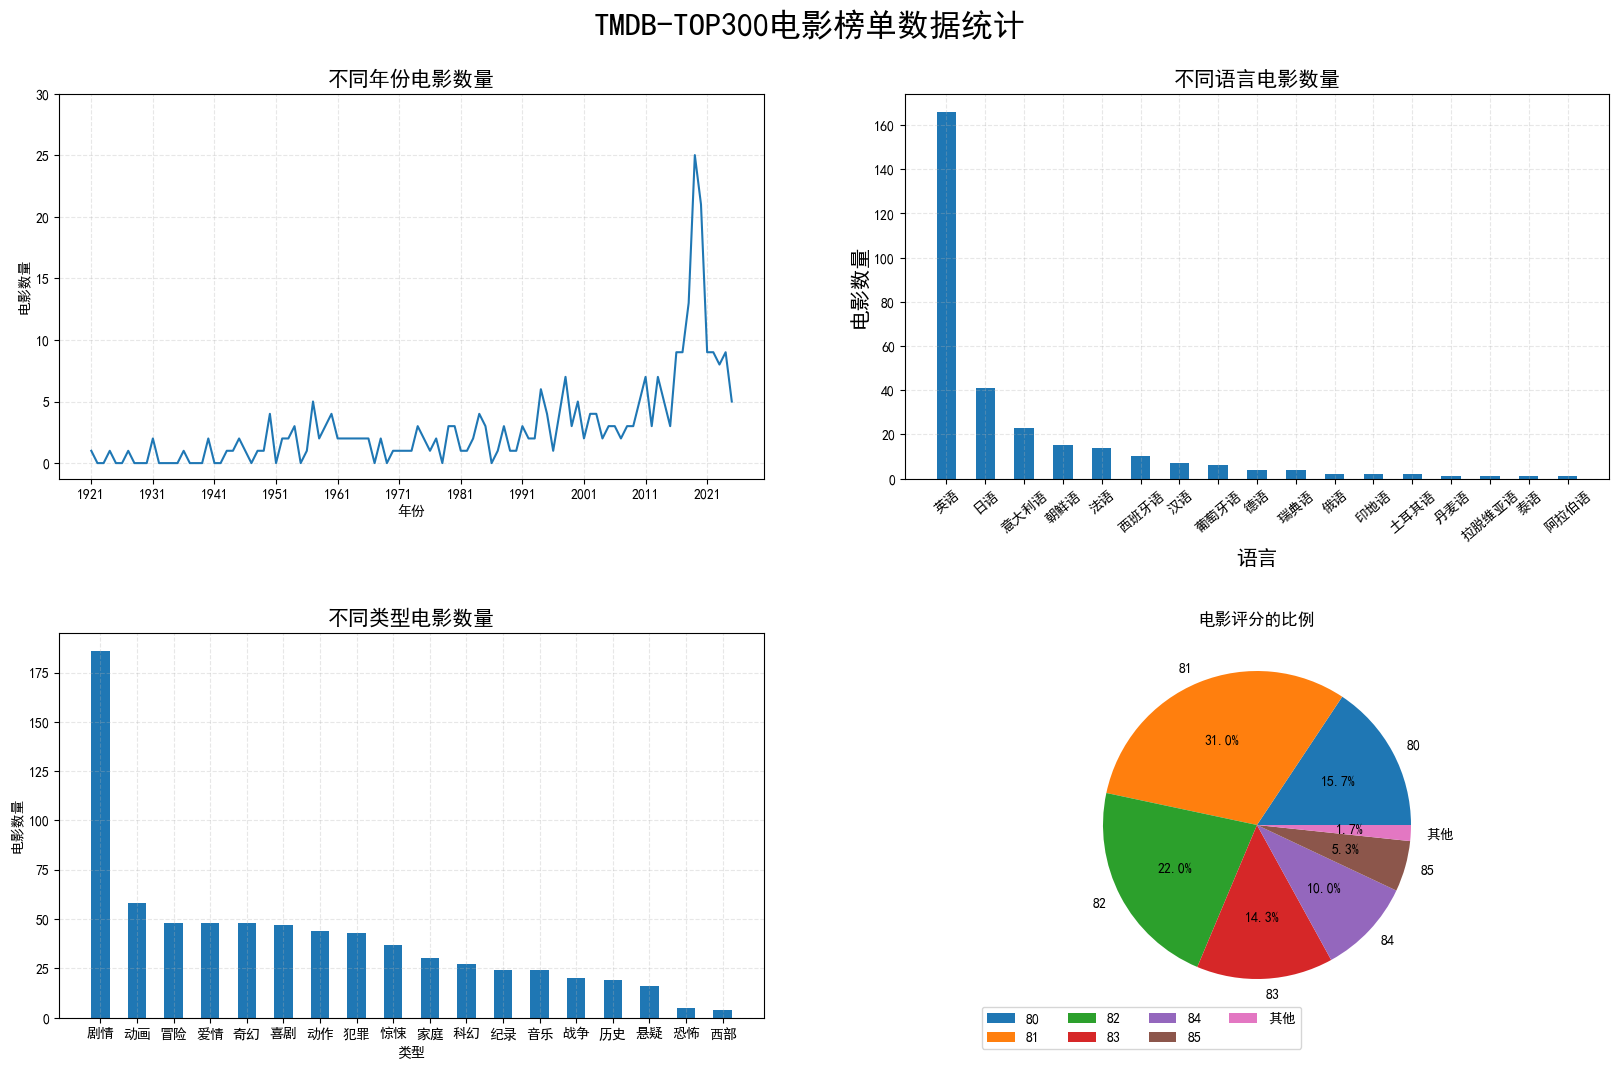

In [120]:
from narwhals import Series
# TMDB-TOP300电影数据统计分析
# 需求1:统计TOP300的电影中，每一年上映的电影数量的变化。(折线图)
# 需求2:统计对比不同语言电影数量。(柱状图)
# 需求3:统计对比不同类型电影数量。(柱状图)
# 需求4:统计对比各个电影评分的比例。(饼状图)

# 1.准备工作:导入依赖库、配置运行时参数、创建子图完成基本布局、加载数据
import pandas as pd
from matplotlib.axes import Axes
import matplotlib.pyplot as plt

# 显示中文
plt.rcParams['font.sans-serif'] = ['SimHei']

# 读取电影数据
# int64 不支持空值
# Int64 支持空值
# float 支持空值
df = pd.read_csv('./resources/movies.csv',usecols=['电影名','年份','上映时间','语言','类型','评分'],dtype={'年份':'Int64'})

# 创建子图
figure,axes = plt.subplots(nrows=2,ncols=2,figsize=(20,12),dpi=100)
figure.suptitle("TMDB-TOP300电影榜单数据统计",fontsize=23,x=0.5,y=0.95) # 添加画布标题 - x控制标题x轴位置 y控制标题y轴位置
figure.subplots_adjust(hspace=0.4,wspace=0.2) # hspace 控制子图之间的垂直距离 wspace控制子图之间的水平距离
# 2.统计TOP300的电影中，每一年上映的电影数量的变化。(折线图)
axes1:Axes = axes[0,0]
axes1.set_title('不同年份电影数量',fontsize=15)
# 2.1 缺失值，异常值处理
df['年份'] = df['年份'].fillna(df['上映时间'].str[:4])
# 2.2 统计各个年份电影的数量
year_count = df.groupby('年份').size()

# 2.3 组装数据
min_year = year_count.index.min()
max_year = year_count.index.max()
# 年份做x轴
x = [i for i in range(min_year,max_year+1)]
# 电影数量做y轴
y = [int(year_count.get(i,0)) for i in x]

axes1.plot(x,y)
# x轴处理
axes1.set_xlabel('年份')
axes1.set_xticks(x[::10])
# y轴处理
axes1.set_ylabel('电影数量')
# y_ticks = [i for i in range(0,31,5)]
axes1.set_yticks(range(0, 31, 5))
axes1.grid(linestyle='--',alpha = 0.3) # 网格线
# 3.统计对比不同语言电影数量。(柱状图)
axes2:Axes = axes[0,1]
# 3.1 统计各个语言电影的数量
# language_count = df.groupby('语言').size()
language_count = df.groupby('语言')['语言'].count().sort_values(ascending=False) # 倒序排序
axes2.bar(language_count.index,language_count.values,width=0.5)
axes2.tick_params(axis='x', rotation=40) # 刻度类型设置
axes2.set_title('不同语言电影数量',fontsize=15)
axes2.set_xlabel('语言',fontsize=15)
axes2.set_ylabel('电影数量',fontsize=15)
axes2.grid(linestyle='--',alpha = 0.3) # 网格线


# 4.统计对比不同类型电影数量。(柱状图)
# 有些有多个类型 需要拆分处理
axes3:Axes = axes[1,0]
type_count = df['类型'].str.split(',').explode().value_counts() # explode 将多个类型拆分 value_counts() 计算数量
axes3.bar(type_count.index,type_count.values,width=0.5)
axes3.set_title('不同类型电影数量',fontsize=15)
axes3.set_xlabel('类型')
axes3.set_ylabel('电影数量')
axes3.grid(linestyle='--',alpha = 0.3) # 网格线

# 5.统计对比各个电影评分的比例。(饼状图)
axes4:Axes = axes[1,1]
# score_count = df.groupby('评分').size()
score_count = df.groupby('评分')['评分'].count()
# 合并小数据(比例<2%)-->其他
total = score_count.sum()
large_scores: Series = score_count.loc[score_count >= total*0.02] # 大数据,  >= 2%
small_scores: Series = score_count.loc[score_count < total*0.02] # 小数据,  < 2%
if small_scores.shape[0] > 0:
    large_scores['其他'] = small_scores.sum()
axes4.pie(large_scores,labels=large_scores.index.tolist(),autopct='%1.1f%%',startangle=0)
axes4.set_title('电影评分的比例')
axes4.legend(loc='lower center',ncol=4,bbox_to_anchor=(0.2,-0.1))

plt.savefig('./resources/TMDB-TOP300.jpg')

plt.show()



In [103]:

score_count = df.groupby('评分').size()
print(score_count)

评分
80    47
81    93
82    66
83    43
84    30
85    16
86     3
87     2
dtype: int64
